<Figure size 400x400 with 0 Axes>

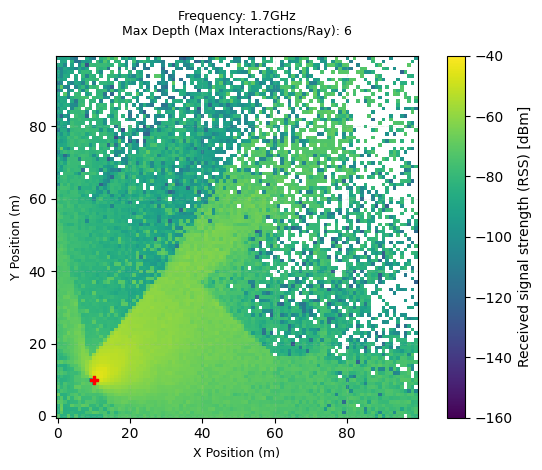


Total paths found: 74

Total interactions found: 444

↳: Counter({'Specular reflection': 236, 'Refraction': 168, 'LOS': 40})


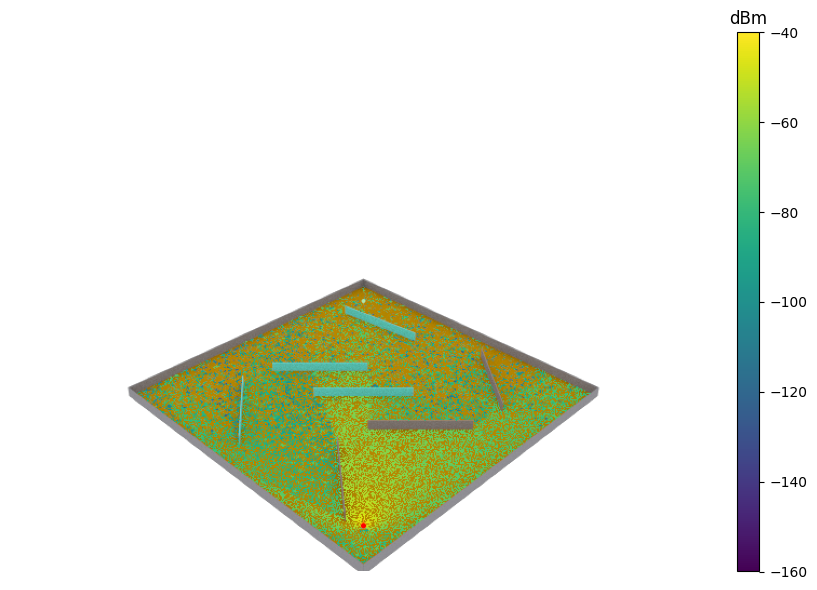

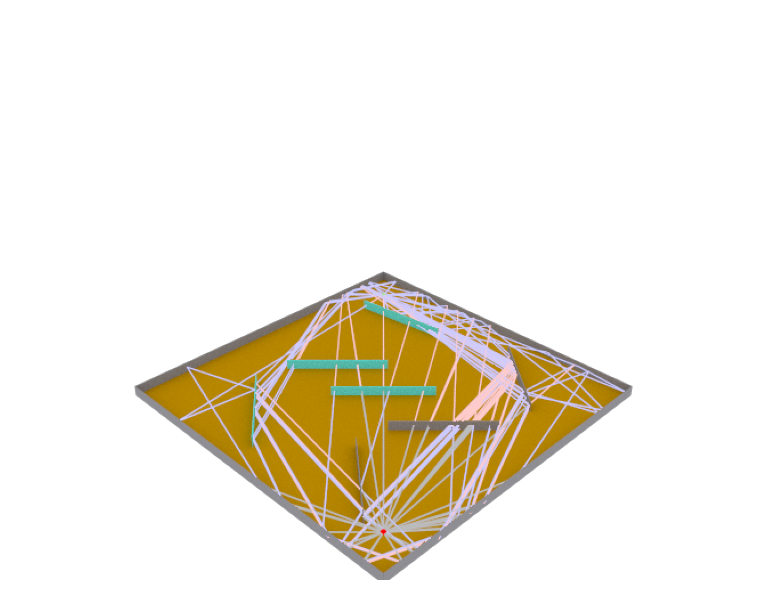

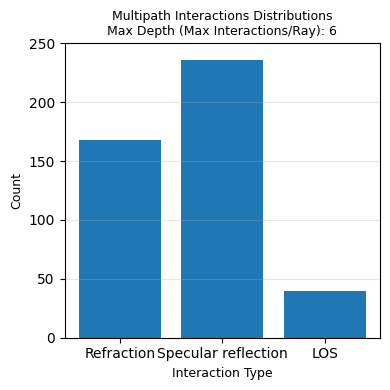

In [1]:
# Import libraries
import numpy as np
from sionna.rt import load_scene, ITURadioMaterial, Transmitter, Receiver, PlanarArray, RadioMapSolver, PathSolver, InteractionType, Camera
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Import scene from blender mitsuba export (.xml)
scene = load_scene("blender-assets/obstacle-room/obstacleroom-100x100m.xml")

# # Optional - Check objects in the scene
# print("Check Scene Objects:")
# print(f"Objects in scene: {list(scene.objects.keys())}")
# print(f"Radio Materials in scene: {list(scene.radio_materials.keys())}")

# Add array for both Tx and Rx to scene
scene.tx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

# Add frequency to scene
carrier_freq = 1.7e9 # In Hz
scene.frequency = carrier_freq

# Deploy Tx and Rx location
tx = Transmitter("tx", [-40, -40, 1.5], [0, 0,0], power_dbm=0)
rx = Receiver("rx", [40, 40, 1.5], [0, 0, 0])

# Point Tx and Rx towards each other
tx.look_at(rx.position)
rx.look_at(tx.position)

# Add Tx and Rx to the scene
scene.add(tx)
scene.add(rx)

# Define maximum depth for a single ray (max number of interactions of a single ray to scene objects)
max_depth = 6

# Plot 2D Radio Map
rm_solver = RadioMapSolver()

rm = rm_solver(
    scene,
    max_depth=max_depth,
    samples_per_tx=10**7,
    cell_size=(1, 1),
    center=[0, 0, 0],
    size=[100, 100],
    orientation=[0, 0, 0]
)

plt.figure(figsize=(4, 4))
rm.show(metric="rss")
plt.title(
    f"Frequency: {carrier_freq/1e9}GHz\nMax Depth (Max Interactions/Ray): {max_depth}",
    fontsize=9,
    pad=15
)
plt.xlabel("X Position (m)", fontsize=9)
plt.ylabel("Y Position (m)", fontsize=9)
plt.clim(-160, -40)
plt.grid(
    alpha=0.2,
    linestyle="--"
)
plt.tight_layout()
plt.show()

# Plot 3D radio map
cam = Camera(
position=(-150, -150, 150),
look_at=rx.position
)

scene.render(
    camera=cam,
    radio_map=rm,

    rm_metric="rss",
    rm_vmax = -40,
    rm_vmin = -160,

    rm_show_color_bar=True,

    show_devices=True,
    show_orientations=True
)

# Plot 3D Paths
p_solver = PathSolver()

paths = p_solver(
    scene,
    max_depth=max_depth,
    samples_per_src=10**7
)

cam = Camera(
position=(-150, -150, 150),
look_at=rx.position
)

scene.render(
    camera=cam,
    paths=paths,
)

# Extract path coefficients (a function return 2 components: a_real, a_imag)
a_real, a_imag = paths.a
a_real = a_real.numpy()
a_imag = a_imag.numpy()

# Reconstruct complex channel coefficients in real and imaginary form
a = a_real + 1j * a_imag

# Check total number of paths
num_paths = a.shape[-1]
print(f"\nTotal paths found: {num_paths}")

# Interaction Types
interactions = paths.interactions.numpy()

counts = Counter()

for interaction in interactions.flatten():
    if interaction == InteractionType.NONE:
        counts["LOS"] += 1
    elif interaction == InteractionType.SPECULAR:
        counts["Specular reflection"] += 1
    elif interaction == InteractionType.DIFFUSE:
        counts["Diffuse reflection"] += 1
    elif interaction == InteractionType.REFRACTION:
        counts["Refraction"] += 1
    elif interaction == InteractionType.DIFFRACTION:
        counts["Diffraction"] += 1

print(f"\nTotal interactions found: {sum(counts.values())}")
print(f"\n↳: {counts}")

plt.figure(figsize=(4,4))
plt.bar(
    counts.keys(),
    counts.values()
)
plt.xlabel("Interaction Type", fontsize=9)
plt.ylabel("Count", fontsize=9)
plt.title(f"Multipath Interactions Distributions\nMax Depth (Max Interactions/Ray): {max_depth}",
          fontsize=9)
plt.ylim(0,250)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# # Optional - Scene Preview
# scene.preview()

# # Optional - Scene Preview (Radio Map)
# rm_solver = RadioMapSolver()

# rm = rm_solver(
#         scene,
#         max_depth=10, # Number of maximum interation allowed per paths
#         samples_per_tx=10**7, # Number of rays launch in transmitter
#         cell_size=(1, 1),
#         center=[0, 0, 0],
#         size=[100, 100], # Size of area to simulate (meter)
#         orientation=[0, 0, 0]
#     )

# scene.preview(
#     radio_map=rm,

#     rm_metric="rss",
#     rm_db_scale=True,

#     rm_vmax = -40,
#     rm_vmin = -160,

#     show_devices=True,
#     show_orientations=True,

#     point_picker=False
# )

# Optional - Scene Preview (Paths)
p_solver = PathSolver()

paths = p_solver(
    scene,
    max_depth=max_depth,
    samples_per_src=10**6
)

scene.preview(
    paths=paths,

    show_devices=True,
    show_orientations=True,

    point_picker=False
)